# Customer Behavior Analysis 

---
## Loading the Dataset

In [127]:
# Importing essential libraries:
# pandas for data manipulation, matplotlib and seaborn for data visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the ecommerce_dataset into a DataFrame
df = pd.read_csv("ecommerce_dataset.csv")  

# Displaying the first 5 rows to inspect the data
df.head()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-2024
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-2024
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-2024
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-2024
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-2024


---
## Understanding the data

In [128]:
# Displaying concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   object 
 1   Product_ID        3660 non-null   object 
 2   Category          3660 non-null   object 
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   object 
 7   Purchase_Date     3660 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 228.9+ KB


In [129]:
# Generating descriptive statistics for numerical columns
df.describe()

,Price (Rs.),Discount (%),Final_Price(Rs.)
count,3660.000000,3660.000000,3660.000000
mean,254.800675,18.825137,206.906579
std,141.682621,14.731338,122.687844
min,10.090000,0.000000,5.890000
25%,134.012500,5.000000,104.512500
50%,253.845000,15.000000,199.185000
75%,377.595000,25.000000,304.117500
max,499.960000,50.000000,496.820000


In [130]:
# Checking for missing values in each column
df.isnull().sum()

User_ID             0
Product_ID          0
Category            0
Price (Rs.)         0
Discount (%)        0
Final_Price(Rs.)    0
Payment_Method      0
Purchase_Date       0
dtype: int64

---
## Cleaning the Data

In [132]:
# Renaming columns for clarity and consistency
df.columns = ['User_ID', 'Product_ID', 'Category', 'Price', 'Discount', 'Final_Price', 'Payment_Method', 'Purchase_Date']

In [133]:
# Converting 'Purchase_Date' column to datetime format 
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], dayfirst=True)

# Checking data types to confirm the conversion
df.dtypes

User_ID                   object
Product_ID                object
Category                  object
Price                    float64
Discount                   int64
Final_Price              float64
Payment_Method            object
Purchase_Date     datetime64[ns]
dtype: object

In [134]:
# Checking for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [136]:
# Validating data by describing it again to spot outliers or unexpected values
df.describe()

,Price,Discount,Final_Price,Purchase_Date
count,3660.000000,3660.000000,3660.000000,3660
mean,254.800675,18.825137,206.906579,2024-06-13 00:46:01.967213056
min,10.090000,0.000000,5.890000,2024-01-01 00:00:00
25%,134.012500,5.000000,104.512500,2024-03-24 00:00:00
50%,253.845000,15.000000,199.185000,2024-06-11 12:00:00
75%,377.595000,25.000000,304.117500,2024-09-03 00:00:00
max,499.960000,50.000000,496.820000,2024-11-21 00:00:00
std,141.682621,14.731338,122.687844,NaN


---
## Analysis 1: Sales by Category

In [137]:
# Analyzing sales by category
# Grouping data by 'Category' and summing 'Final_Price' for each
# Sorting the categories in descending order of total sales
category_sales = df.groupby('Category')['Final_Price'].sum().sort_values(ascending=False)

# Printing the total sales per category
print(category_sales)

Category
Clothing          115314.84
Books             111149.35
Home & Kitchen    110328.08
Sports            108518.79
Toys              107289.69
Beauty            104215.10
Electronics       100462.23
Name: Final_Price, dtype: float64


**Observation:**  
Clothing generates the highest sales at Rs. 115,314.84, followed by Books (Rs. 111,149.35) and Home & Kitchen (Rs. 110,328.08). Electronics (Rs. 100,462.23) generates the lowest sales among the categories.

**Meaning:**  
This shows that mid-range and everyday categories like Clothing, Books, and Home & Kitchen drive the most revenue, while higher-value categories like Electronics contribute less, suggesting that revenue in this store depends more on the volume of sales than the price per item.

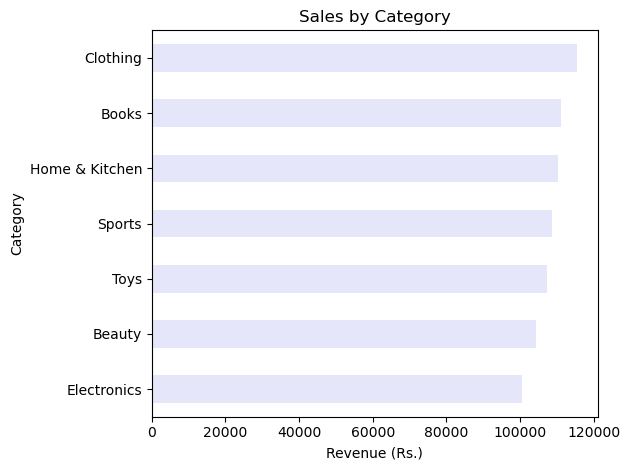

In [138]:
# Getting sales by category
# Grouping data by 'Category' and summing 'Final_Price' for each
# Sorting categories in ascending order for better visualization
category_sales = df.groupby('Category')['Final_Price'].sum().sort_values()

# Plotting horizontal bar chart for visualizing sales by category
category_sales.plot(kind='barh', color='lavender')

# Adding chart title and axis labels
plt.title("Sales by Category")
plt.xlabel("Revenue (Rs.)")
plt.ylabel("Category")

# Adjusting layout to prevent label overlap
plt.tight_layout()  

# Displaying the chart
plt.show()

---
## Analysis 2: Payment Method Analysis

In [139]:
# Analyzing payment methods
# Counting the number of transactions for each payment method
df['Payment_Method'].value_counts()

Payment_Method
Credit Card         760
UPI                 757
Debit Card          731
Net Banking         716
Cash on Delivery    696
Name: count, dtype: int64

**Observation:**  
Credit Card is the most used payment method (760 transactions), followed closely by UPI (757), Debit Card (731), Net Banking (716), and Cash on Delivery (696), which is the least used.

**Meaning:**  
Customers slightly prefer digital payments like Credit Card and UPI over Cash on Delivery. This indicates that the store should continue optimizing digital payment options and encourage online transactions for convenience and faster processing.

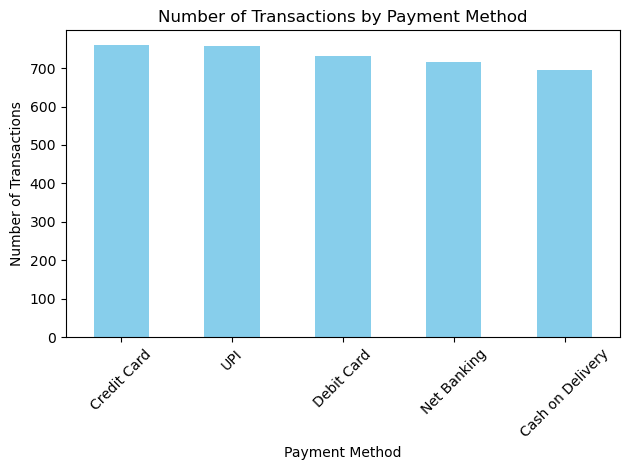

In [140]:
# Visualizing payment methods
# Plotting a vertical bar chart for transaction counts by payment method
df['Payment_Method'].value_counts().plot(kind='bar', color='skyblue')

# Adding chart title and axis labels
plt.title("Number of Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adjusting layout to prevent label overlap
plt.tight_layout()  

# Displaying the chart
plt.show()

---
## Analysis 3: Monthly Sales Trend

In [141]:
# Ensuring 'Purchase_Date' column is in datetime format
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# Extracting month number and abbreviated month name from 'Purchase_Date'
df['Month'] = df['Purchase_Date'].dt.month
df['Month_Name'] = df['Purchase_Date'].dt.strftime('%b')  

# Calculating total sales for each month
# Reindexing months to display in calendar order
monthly_sales = df.groupby('Month_Name')['Final_Price'].sum().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)

# Printing monthly sales totals
print(monthly_sales)

Month_Name
Jan    69009.43
Feb    69186.34
Mar    71325.40
Apr    74365.13
May    68837.25
Jun    64256.66
Jul    72798.23
Aug    71506.96
Sep    68043.09
Oct    76034.51
Nov    51915.08
Dec         NaN
Name: Final_Price, dtype: float64


**Observation:**  
Sales peak in October (Rs. 76,034.51) and are lowest in November (Rs. 51,915.08). Other months fluctuate between Rs. 64,256.66 (June) and Rs. 74,365.13 (April). December has no sales data.

**Meaning:**  
There is a clear seasonal trend with higher sales in April and October, possibly due to promotional events or festivals. Lower sales in June and November indicate periods of low customer activity. This information can help the store plan marketing campaigns and inventory ahead of peak months.

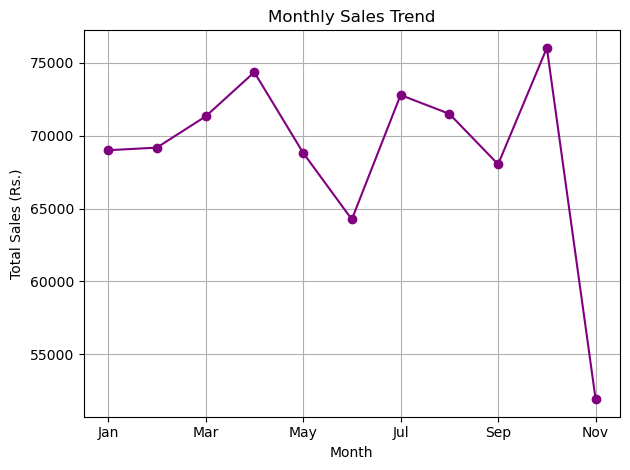

In [142]:
# Visualizing monthly sales trend
# Plotting a line chart with markers for each month
monthly_sales.plot(kind='line', marker='o', color='purple')

# Adding chart title and axis labels
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (Rs.)")

# Adding grid for easier trend reading
plt.grid(True)

# Adjusting layout to prevent label overlap
plt.tight_layout()  

# Displaying the chart
plt.show()

---
## Analysis 4: Top Customer

In [143]:
# Grouping data by 'User_ID' and summing 'Final_Price' to calculate total spending per customer
# Sorting in descending order and selecting top 10 customers
top_customers = df.groupby('User_ID')['Final_Price'].sum().sort_values(ascending=False).head(10)

# Printing top 10 customers by total spending
print(top_customers)

User_ID
8b885340    496.82
20797b76    495.02
d8970dd2    493.04
da7bc76a    492.41
68722b9b    491.70
05e6557c    487.06
67abda0a    486.79
d646700c    484.56
edb89577    480.49
f9e89622    479.63
Name: Final_Price, dtype: float64


**Observation:**  
The top 10 customers spend between Rs. 496.82 and Rs. 479.63, with User_ID `8b885340` being the highest spender at Rs. 496.82 and `f9e89622` the lowest among the top 10 at Rs. 479.63.

**Meaning:**  
A small group of customers contributes disproportionately to revenue. Identifying and targeting these high-value customers with personalized offers or loyalty programs could increase overall sales and customer retention.

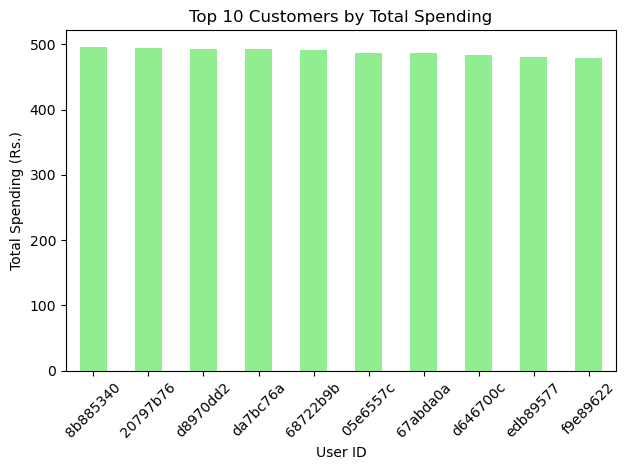

In [144]:
# Visualizing top customers
# Plotting a vertical bar chart for the top 10 customers by spending
top_customers.plot(kind='bar', color='lightgreen')

# Adding chart title and axis labels
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("User ID")
plt.ylabel("Total Spending (Rs.)")

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adjusting layout to prevent label overlap
plt.tight_layout()  

# Displaying the chart
plt.show()

---
## Analysis 5: Discount Impact on Sales

In [145]:
# Calculating average discount and average sales per category
discount_sales = df.groupby('Category')[['Discount', 'Final_Price']].mean()

# Printing the average discount and sales for each category
print(discount_sales)

                 Discount  Final_Price
Category                              
Beauty          18.475248   206.366535
Books           19.035581   208.144850
Clothing        17.919021   217.165424
Electronics     19.267068   201.731386
Home & Kitchen  19.608379   200.961894
Sports          19.326923   208.689981
Toys            18.126195   205.142811


**Observation:**  
Categories with lower average discounts, like Clothing (17.92%) and Beauty (18.48%), have higher average sales (Rs. 217.17 and Rs. 206.37 respectively). Categories with higher average discounts, like Home & Kitchen (19.61%) and Electronics (19.27%), have lower average sales (Rs. 200.96 and Rs. 201.73 respectively).  

**Meaning:**  
Offering higher discounts does not necessarily increase average sales. Some categories maintain high sales even with lower discounts, indicating strong demand. This suggests that the store should optimize discount strategies by category rather than applying uniform discounts across all products.

/var/folders/b9/55rwc5hx2ddfymf3z7xdh1f40000gn/T/ipykernel_29938/359644500.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = discount_sales['Discount'][i]
/var/folders/b9/55rwc5hx2ddfymf3z7xdh1f40000gn/T/ipykernel_29938/359644500.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = discount_sales['Final_Price'][i]


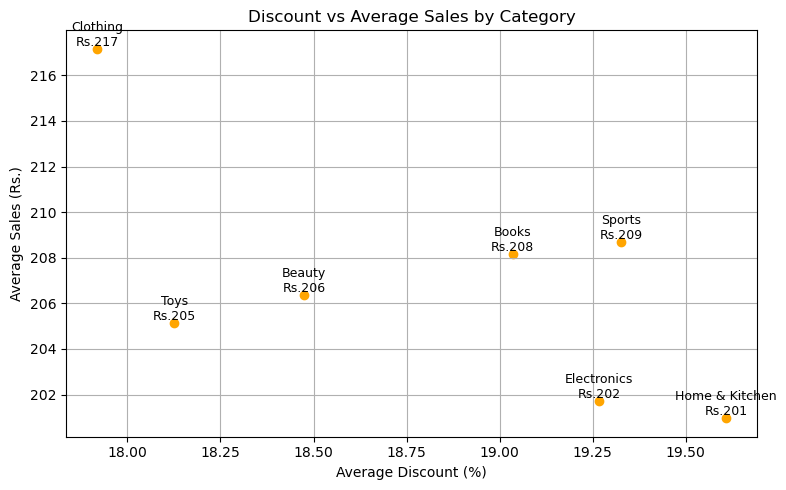

In [146]:
# Visualizing relationship between discount and average sales
# Creating a scatter plot with 'Discount' on x-axis and 
# 'Final_Price' on y-axis
plt.figure(figsize=(8,5))
plt.scatter(discount_sales['Discount'], discount_sales['Final_Price'], color='orange')

# Annotating each point with category name and average sales value
for i, cat in enumerate(discount_sales.index):
    x = discount_sales['Discount'][i]
    y = discount_sales['Final_Price'][i]
    plt.text(x, y, f'{cat}\nRs.{y:.0f}', fontsize=9, ha='center', va='bottom')

# Adding chart title and axis labels
plt.title("Discount vs Average Sales by Category")
plt.xlabel("Average Discount (%)")
plt.ylabel("Average Sales (Rs.)")

# Adding grid for better readability
plt.grid(True)

# Adjusting layout to prevent overlapping elements
plt.tight_layout()  

# Displaying the chart
plt.show()

---
## Analysis 6: Purchase Volume by Product

In [147]:
# Counting the number of times each product was purchased
# Selecting the top 10 most purchased products
product_volume = df['Product_ID'].value_counts().head(10) 
print(product_volume)

Product_ID
f414122f-e    1
fa0af2c6-1    1
df20c732-7    1
9c83496b-c    1
49cf6bb4-d    1
233f387c-1    1
48db1429-2    1
d858c042-1    1
2883c4ac-f    1
dadc64fc-7    1
Name: count, dtype: int64


**Observation:**  
Each Product_ID in the dataset was purchased only once. This means there is no single product that dominates sales volume.  

**Meaning:**  
The dataset contains a wide variety of products purchased with roughly equal frequency. Because of this, analyzing individual product sales does not reveal meaningful trends. For actionable insights, purchase volume should be considered at the Category or Sub-Category level, which aggregates multiple products and shows which types of products are most popular with customers.

---
## Analysis 7: Purchase Volume by Category

In [148]:
# Counting the number of purchases per category
category_volume = df['Category'].value_counts()
print(category_volume)

Category
Home & Kitchen    549
Books             534
Clothing          531
Toys              523
Sports            520
Beauty            505
Electronics       498
Name: count, dtype: int64


**Observation:**  
The Home & Kitchen category has the highest number of purchases (549), followed by Books (534) and Clothing (531). Categories like Beauty (505) and Electronics (498) have fewer purchases.

**Meaning:**  
This indicates which product categories are most popular with customers. High-volume categories such as Home & Kitchen, Books, and Clothing suggest strong customer demand, so the store should ensure sufficient inventory and consider targeted marketing strategies for these categories. Categories with lower purchase volumes may need promotions or bundled offers to increase sales.

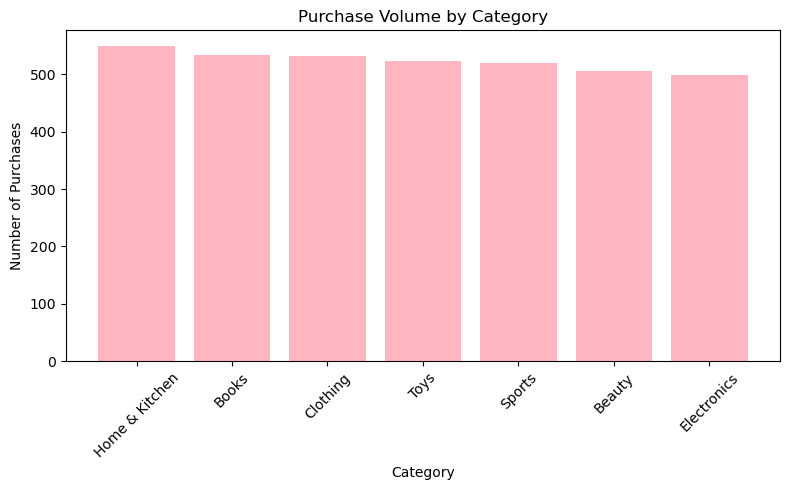

In [149]:
# Visualizing purchase volume by category
# Creating a vertical bar chart with categories on x-axis and number of purchases on y-axis
plt.figure(figsize=(8,5))
plt.bar(category_volume.index, category_volume.values, color='lightpink')

# Adding chart title and axis labels
plt.title("Purchase Volume by Category")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adjusting layout to prevent overlapping elements
plt.tight_layout()  

# Displaying the chart
plt.show()

---
## Analysis 8: Category vs Payment Method

In [150]:
# Creating a cross-tabulation of 'Category' vs 'Payment_Method'
# Counting number of purchases for each category-payment method combination
category_payment = pd.crosstab(df['Category'], df['Payment_Method'])
print(category_payment)

Payment_Method  Cash on Delivery  Credit Card  Debit Card  Net Banking  UPI
Category                                                                   
Beauty                        99          100          90           96  120
Books                        103          109         105          107  110
Clothing                     109          109         107           98  108
Electronics                   92          105          99          100  102
Home & Kitchen                96          119         104          112  118
Sports                       106          113         117           91   93
Toys                          91          105         109          112  106


**Observation:**  
Customers show different payment preferences depending on the product category. Home & Kitchen purchases are highest using Credit Card (119) and UPI (118). Books are mostly purchased via Credit Card (109) and UPI (110). Beauty is dominated by UPI (120), while Clothing, Electronics, Sports, and Toys show fairly balanced usage across all payment methods.

**Meaning:**  
This indicates that payment method preference varies by product type. High-value or essential categories like Home & Kitchen and Books favor digital payments (Credit Card, UPI), suggesting customers trust these methods for larger purchases. For categories with more even distribution, offering flexible payment options ensures convenience. Retailers can use this insight to promote certain payment methods strategically and improve the overall customer experience.

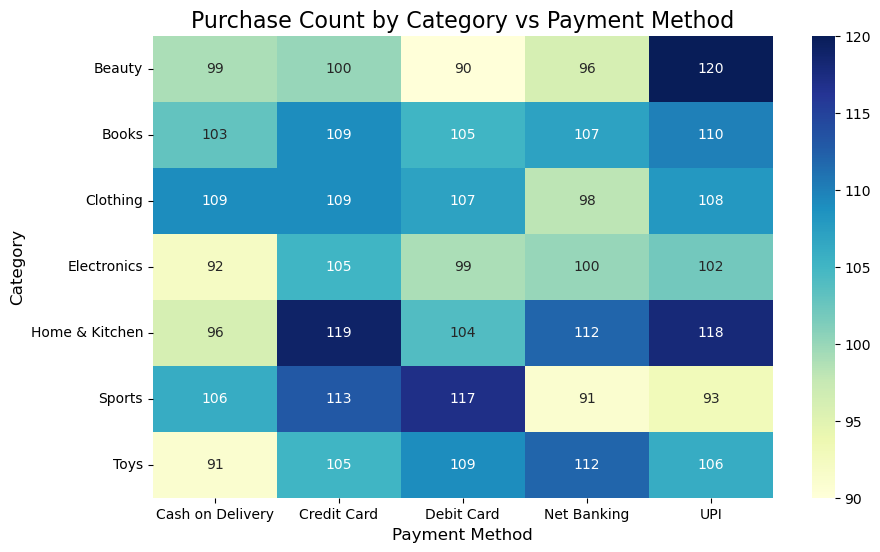

In [151]:
# Visualizing category vs payment method using a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(category_payment, annot=True, fmt="d", cmap="YlGnBu")

# Adding chart title and axis labels with font sizing
plt.title("Purchase Count by Category vs Payment Method", fontsize=16)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Category", fontsize=12)

# Displaying the heatmap
plt.show()

---
## Analysis 9: Customer Segmentation by Spending

In [152]:
# Calculating total spending per customer
# Grouping data by 'User_ID' and summing 'Final_Price'
customer_spend = df.groupby('User_ID')['Final_Price'].sum().sort_values(ascending=False)

# Displaying top 10 customers by total spending
customer_spend.head(10)

User_ID
8b885340    496.82
20797b76    495.02
d8970dd2    493.04
da7bc76a    492.41
68722b9b    491.70
05e6557c    487.06
67abda0a    486.79
d646700c    484.56
edb89577    480.49
f9e89622    479.63
Name: Final_Price, dtype: float64

In [153]:
# Segmenting customers into High, Medium, and Low Value based on spending quantiles
# Calculating 80th percentile for high-value threshold and 20th percentile for low-value threshold
top_20 = customer_spend.quantile(0.8)
bottom_20 = customer_spend.quantile(0.2)

# Defining a function to assign customer segments based on spending
def segment(spend):
    if spend >= top_20:
        return 'High Value'
    elif spend <= bottom_20:
        return 'Low Value'
    else:
        return 'Medium Value'

# Applying segmentation function to each customer
customer_segment = customer_spend.apply(segment)

# Counting number of customers in each segment
customer_segment.value_counts()

Final_Price
Medium Value    2196
High Value       732
Low Value        732
Name: count, dtype: int64

**Observation:**  
Customers can be grouped into three segments based on total spending: High Value (732 customers), Medium Value (2196 customers), and Low Value (732 customers). The majority of customers fall in the Medium Value segment, while a smaller portion are High or Low Value.

**Meaning:**  
This shows that while most customers contribute moderately to revenue, a smaller group of High Value customers generates a disproportionately large portion of total sales. Retailers should prioritize loyalty programs, exclusive offers, or targeted promotions for High Value customers to maximize revenue, while encouraging Medium and Low Value customers to increase purchases through discounts, bundles, or engagement campaigns.

---
## Analysis 10: Category-wise Average Discount vs Revenue

In [154]:
# Grouping data by 'Category' and calculating average discount and average revenue
category_discount_revenue = df.groupby('Category')[['Discount', 'Final_Price']].mean()

# Sorting categories by average revenue in descending order to highlight high-revenue categories
category_discount_revenue = category_discount_revenue.sort_values(by='Final_Price', ascending=False)

# Displaying the average discount and revenue per category
print(category_discount_revenue)

                 Discount  Final_Price
Category                              
Clothing        17.919021   217.165424
Sports          19.326923   208.689981
Books           19.035581   208.144850
Beauty          18.475248   206.366535
Toys            18.126195   205.142811
Electronics     19.267068   201.731386
Home & Kitchen  19.608379   200.961894


**Observation:**  
Across product categories, the average discount and revenue vary noticeably. Clothing generates the highest revenue at approximately 217.17 Rs. while maintaining a moderate average discount of around 17.92%. Sports and Books have slightly higher discounts, roughly 19–19.33%, yet their revenue is slightly lower, around 208.69 Rs. and 208.14 Rs., respectively. Beauty and Toys see moderate discounts near 18.13–18.48% with revenues of about 205.14–206.37 Rs. Electronics and Home & Kitchen have the highest discounts, near 19.27–19.61%, but generate the lowest revenue, around 201.73 Rs. and 200.96 Rs., respectively.

**Meaning:**  
This indicates that higher discounts do not necessarily translate into higher revenue. Categories like Clothing, which maintain moderate discounts, can achieve higher revenue due to strong demand. Retailers can use this insight to optimize pricing strategies: keeping lower discounts on high-revenue categories to maximize profit, while selectively applying higher discounts on less sensitive categories to boost sales without significantly affecting overall revenue.

/var/folders/b9/55rwc5hx2ddfymf3z7xdh1f40000gn/T/ipykernel_29938/2192519723.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(category_discount_revenue['Discount'][i], category_discount_revenue['Final_Price'][i]+1, cat,


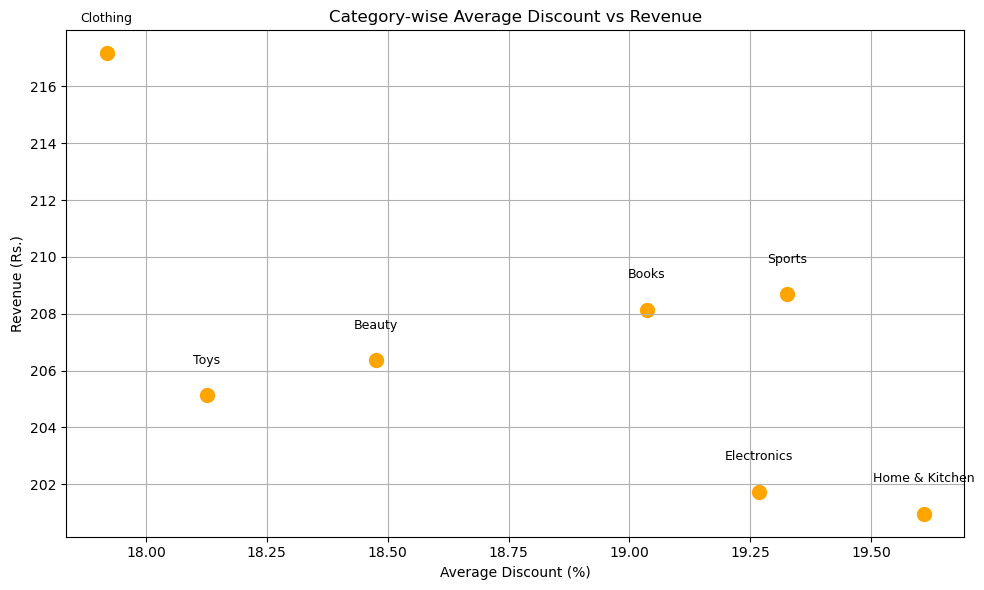

In [155]:
# Creating scatter plot for category-wise average discount vs revenue
plt.figure(figsize=(10,6))
plt.scatter(category_discount_revenue['Discount'], category_discount_revenue['Final_Price'], color='orange', s=100)

# Annotating each point with category name
for i, cat in enumerate(category_discount_revenue.index):
    plt.text(category_discount_revenue['Discount'][i], category_discount_revenue['Final_Price'][i]+1, cat, 
             ha='center', va='bottom', fontsize=9)

# Adding chart title, axis labels, and grid for clarity
plt.title("Category-wise Average Discount vs Revenue")
plt.xlabel("Average Discount (%)")
plt.ylabel("Revenue (Rs.)")
plt.grid(True)

# Adjusting layout to prevent overlapping elements
plt.tight_layout()  

# Displaying the scatter plot
plt.show()

---
## Analysis 11: Customer Segmentation by Spending

In [156]:
# Extracting month names from 'Purchase_Date'
df['Month'] = df['Purchase_Date'].dt.month_name()

# Grouping data by Month and Category, calculating total revenue per category
monthly_category_trend = df.groupby(['Month', 'Category'])['Final_Price'].sum().unstack()

# Reordering months to ensure proper chronological order
months_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_category_trend = monthly_category_trend.reindex(months_order)

# Displaying the monthly revenue trend by category
print(monthly_category_trend)

Category     Beauty     Books  Clothing  Electronics  Home & Kitchen  \
Month                                                                  
January    10909.32   8858.16  10664.28      8439.91        10421.69   
February   12039.20   7516.03  10471.59     11238.46        10338.02   
March      11088.45   8495.20  12820.30      8216.37        10063.40   
April       8542.71   9346.81  15876.86      7747.77        11814.25   
May        10688.15  10194.79   8243.46      9453.03         8723.17   
June        5934.21   8916.94   8109.12     11638.59         8029.62   
July        8895.84  11455.91   9840.52     10889.77        10670.41   
August      8106.25  10437.67   8853.21     10592.97        12812.65   
September  11429.78  11260.05   9351.98      5321.05        11340.52   
October     9977.46  15271.10  11994.27     11613.64         9040.88   
November    6603.73   9396.69   9089.25      5310.67         7073.47   
December        NaN       NaN       NaN          NaN            

**Observation:**  
The monthly revenue for each product category shows clear seasonal variations. Clothing peaks in April with 15,876 Rs., while Books reach their highest in October at 15,271 Rs. Home & Kitchen shows strong sales in August at 12,813 Rs., and Electronics have notable peaks in February and June. Sports and Toys have more fluctuating patterns, with Sports peaking in March at 12,143 Rs. and Toys reaching 13,391 Rs. in June. Some months, such as December, have missing data, suggesting either incomplete records or no sales captured.

**Meaning:**  
This indicates that customer demand for different categories varies throughout the year, reflecting seasonal trends or promotional periods. Retailers can leverage these insights to plan inventory, marketing campaigns, and sales promotions strategically. For example, stocking more Clothing in the months leading up to April or preparing for higher Book sales before October can help meet demand efficiently. Similarly, understanding peak months for Home & Kitchen, Sports, and Toys allows better resource allocation and targeted campaigns to maximize revenue.

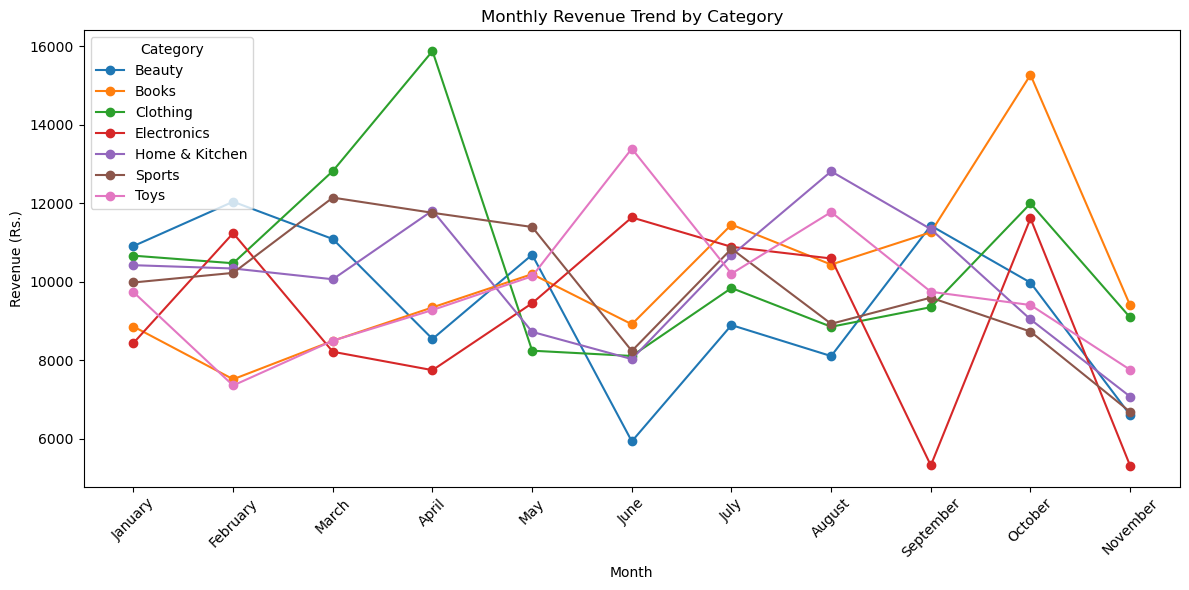

In [157]:
# Plotting monthly revenue trend for each category
plt.figure(figsize=(12,6))
for category in monthly_category_trend.columns:
    plt.plot(monthly_category_trend.index, monthly_category_trend[category], marker='o', label=category)

# Adding chart title, axis labels, rotating x-axis labels, and legend
plt.title("Monthly Revenue Trend by Category")
plt.xlabel("Month")
plt.ylabel("Revenue (Rs.)")
plt.xticks(rotation=45)
plt.legend(title="Category")

# Adjusting layout to prevent overlapping elements
plt.tight_layout()  

# Displaying the line chart
plt.show()

---
## Analysis 12: Payment Method vs Spending

In [158]:
# Grouping data by 'Payment_Method' and calculating total spending per method
payment_spending = df.groupby('Payment_Method')['Final_Price'].sum().sort_values(ascending=False)

# Displaying total spending per payment method
print(payment_spending)

Payment_Method
Credit Card         156018.02
UPI                 154684.81
Debit Card          153362.26
Net Banking         146804.40
Cash on Delivery    146408.59
Name: Final_Price, dtype: float64


**Observation:**  
Among all payment methods, Credit Card has the highest total spending (156,018), followed closely by UPI (154,685) and Debit Card (153,362). Net Banking (146,804) and Cash on Delivery (146,409) show comparatively lower spending.

**Meaning:**  
This indicates that customers prefer digital payment methods, especially Credit Cards and UPI, for higher-value purchases. Cash on Delivery and Net Banking are used less frequently for total spending, suggesting these methods might be more common for smaller transactions. Retailers can leverage this insight to promote preferred digital payment options, offer incentives for less-used methods, or tailor marketing strategies to encourage adoption of high-spending payment methods.

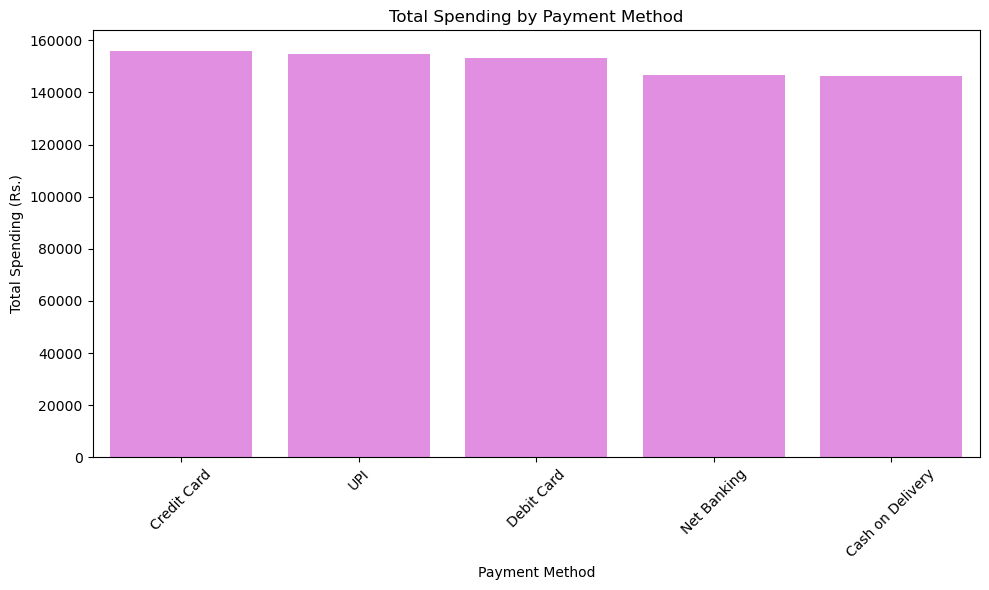

In [159]:
# Visualizing total spending by payment method using a bar plot
plt.figure(figsize=(10,6))
sns.barplot(x=payment_spending.index, y=payment_spending.values, color='Violet')

# Adding chart title and axis labels
plt.title("Total Spending by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Spending (Rs.)")

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adjusting layout to prevent overlapping elements
plt.tight_layout()  

# Displaying the chart
plt.show()

---
## Analysis 13: Top Products Contribution

In [160]:
# Calculating total revenue per product and selecting top 10 products
top_products = df.groupby('Product_ID')['Final_Price'].sum().sort_values(ascending=False).head(10)

# Displaying top 10 products by revenue contribution
print(top_products)

Product_ID
5a4c2797-7    496.82
2a8fff8b-4    495.02
475d4cf1-c    493.04
e88dc97f-5    492.41
67d7c91c-b    491.70
128bb94a-4    487.06
28714133-6    486.79
585b0773-2    484.56
3be497cb-0    480.49
6390f2ea-8    479.63
Name: Final_Price, dtype: float64


**Observation:**  
The top 10 products contribute significantly to revenue, with the highest-grossing product generating 496.82 and the 10th highest at 479.63. The revenue difference between these top products is relatively small, indicating a consistent performance among the leading items.

**Meaning:**  
This shows that a small set of products drives a noticeable portion of total revenue. Retailers should ensure these top products are always in stock, consider highlighting them in promotions, and possibly bundle them with other items to maximize sales. Monitoring these high-performing products closely can also help forecast demand and optimize inventory management.

/var/folders/b9/55rwc5hx2ddfymf3z7xdh1f40000gn/T/ipykernel_29938/3020070752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="magma")


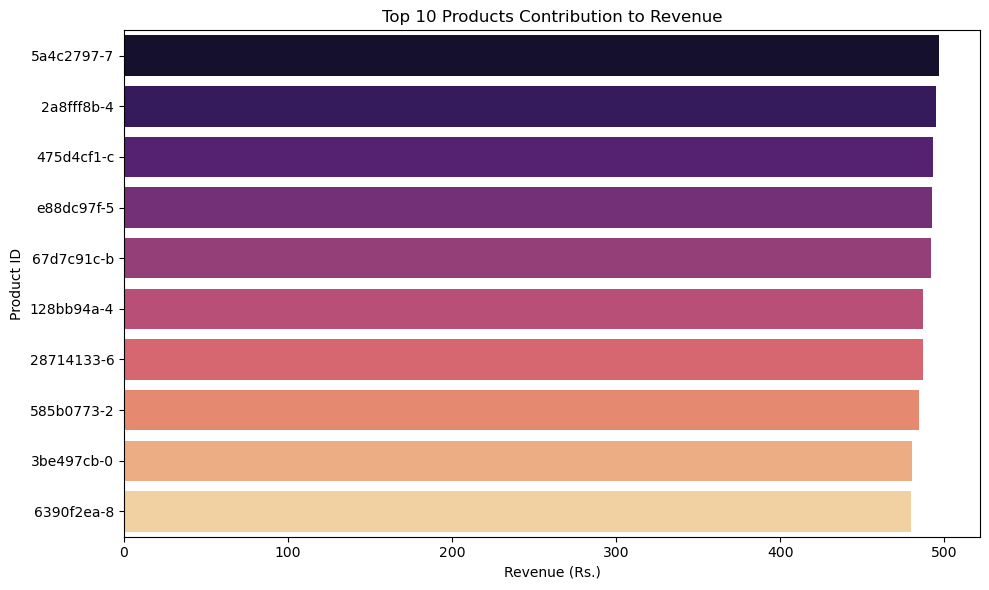

In [161]:
# Visualizing top 10 products contributing to revenue using a horizontal bar plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="magma")

# Adding chart title and axis labels
plt.title("Top 10 Products Contribution to Revenue")
plt.xlabel("Revenue (Rs.)")
plt.ylabel("Product ID")

# Adjusting layout to prevent overlapping elements
plt.tight_layout()  

# Displaying the chart
plt.show()